<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.8202 acc 0.729 | val loss 0.4926 acc 0.795 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.5515 acc 0.794 | val loss 0.6242 acc 0.730


[ConvNeXt-Tiny] Epoch   3/100 | LR: 6.78e-05 | train loss 0.4353 acc 0.834 | val loss 0.4409 acc 0.789 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 6.78e-05 | train loss 0.2962 acc 0.893 | val loss 0.6472 acc 0.795


[ConvNeXt-Tiny] Epoch   5/100 | LR: 6.78e-05 | train loss 0.2379 acc 0.921 | val loss 0.5917 acc 0.806


...

[ConvNeXt-Tiny] Epoch  12/100 | LR: 6.78e-05 | train loss 0.0425 acc 0.988 | val loss 0.6028 acc 0.850


[ConvNeXt-Tiny] Epoch  13/100 | LR: 6.78e-05 | train loss 0.0046 acc 0.999 | val loss 0.5565 acc 0.865


[ConvNeXt-Tiny] Epoch  14/100 | LR: 6.78e-05 | train loss 0.0020 acc 1.000 | val loss 0.5931 acc 0.877


[ConvNeXt-Tiny] Epoch  15/100 | LR: 6.78e-05 | train loss 0.0361 acc 0.995 | val loss 0.5263 acc 0.845


[ConvNeXt-Tiny] Epoch  16/100 | LR: 6.78e-05 | train loss 0.1806 acc 0.950 | val loss 0.5185 acc 0.859

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 16.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3980)


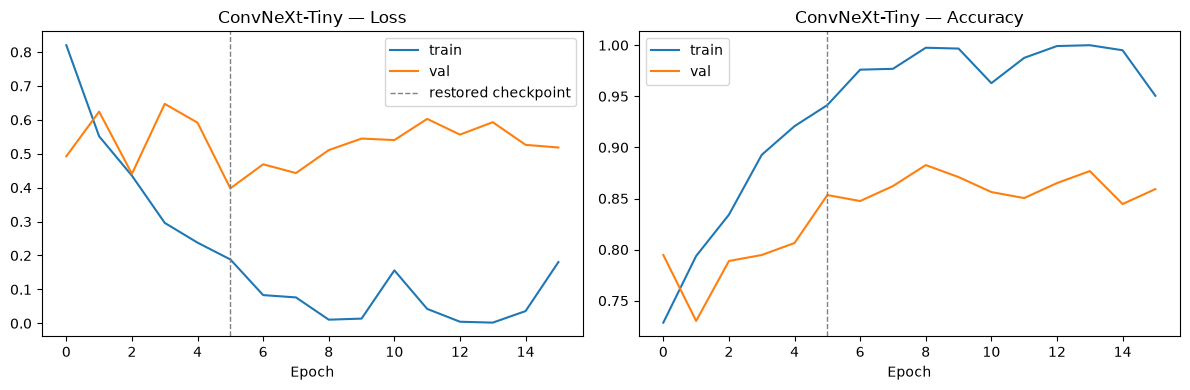

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.800


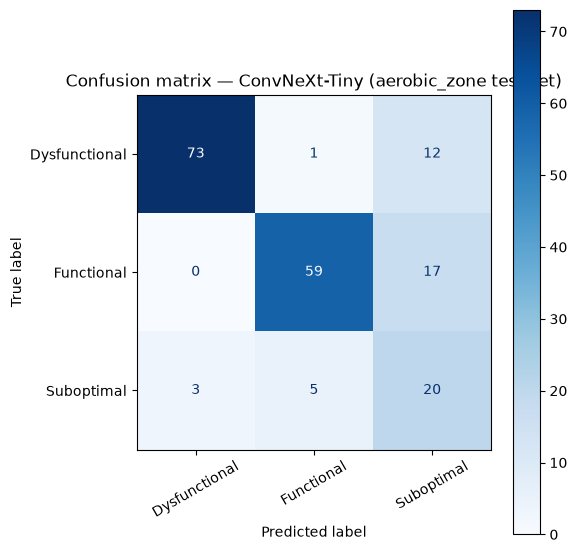

               precision    recall  f1-score   support

Dysfunctional      0.961     0.849     0.901        86
   Functional      0.908     0.776     0.837        76
   Suboptimal      0.408     0.714     0.519        28

     accuracy                          0.800       190
    macro avg      0.759     0.780     0.753       190
 weighted avg      0.858     0.800     0.819       190



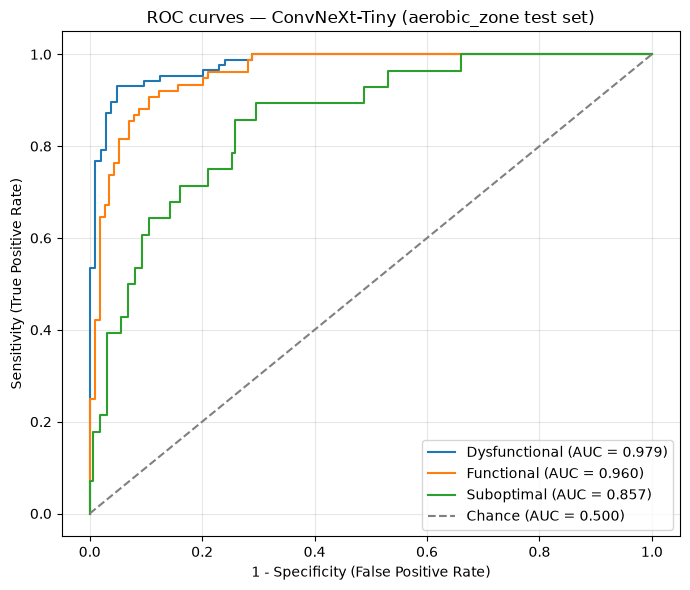

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.979
  Functional     : 0.960
  Suboptimal     : 0.857

Mean AUC (over 3/3 classes with test examples): 0.932


(np.float64(0.8),
 {'Dysfunctional': 0.9786449016100178,
  'Functional': 0.9596029547553093,
  'Suboptimal': 0.8567019400352734})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_convnext_tiny_stratified.pkl
Saved model weights to ../models/aerobic_zone_convnext_tiny_cnn.pt
